House Prices - Advanced Regression Techniques -
Harshal Samuel Albert
ASU ID - 1234243844.


In [74]:
!pip install vecstack

In [75]:
from vecstack import stacking
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from math import sqrt
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [76]:
#Read training data file
trainfile = '/content/train_home.csv'
trainData = pd.read_csv(trainfile)

#Read test data file
testfile = '/content/test_home.csv'
testData = pd.read_csv(testfile)

print(trainData.shape)
print(testData.shape)

(1460, 81)
(1459, 80)


EDA

In [77]:
trainData.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [78]:
trainData['SalePrice'].describe()


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


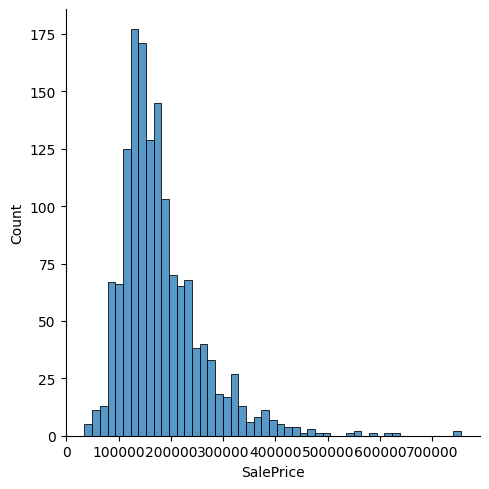

In [79]:
sns.displot(trainData['SalePrice']);


DATA PRE-PROCESSING

In [80]:
train_ID = trainData['Id']
test_ID = testData['Id']

#Now drop the  'Id' colum since it's unnecessary for  the prediction process.
trainData.drop("Id", axis = 1, inplace = True)
testData.drop("Id", axis = 1, inplace = True)

In [81]:
Ytrain = trainData['SalePrice']
combinedData = pd.concat([trainData,testData], keys=[0,1])
combinedData.drop(['SalePrice'], axis=1, inplace=True)
combinedData.shape

(2919, 79)

MISSING DATA

In [82]:
missing_values = combinedData.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0
PoolQC,2909
MiscFeature,2814
Alley,2721
Fence,2348
MasVnrType,1766
FireplaceQu,1420
LotFrontage,486
GarageFinish,159
GarageQual,159
GarageCond,159


In [83]:
na_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in na_cols:
    combinedData[col].fillna("None", inplace=True)

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    combinedData[col].fillna(0, inplace=True)

combinedData["LotFrontage"] = combinedData.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

combinedData.drop(['Utilities'], axis=1, inplace = True)

mode_cols = ['MSZoning', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType', 'Electrical']
for col in mode_cols:
    mode = combinedData[col].mode()[0]
    combinedData[col].fillna(mode, inplace=True)



In [84]:
missing_values = combinedData.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0


CATEGORICAL FEATURES

In [85]:
#Changing features into a categorical variable

combinedData['MSSubClass'] = combinedData['MSSubClass'].apply(str)
combinedData['OverallCond'] = combinedData['OverallCond'].astype(str)
combinedData['OverallQual'] = combinedData['OverallQual'].astype(str)

In [86]:
combinedData.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2919 entries, (0, 0) to (1, 1458)
Data columns (total 78 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   LotConfig      2919 non-null   object 
 9   LandSlope      2919 non-null   object 
 10  Neighborhood   2919 non-null   object 
 11  Condition1     2919 non-null   object 
 12  Condition2     2919 non-null   object 
 13  BldgType       2919 non-null   object 
 14  HouseStyle     2919 non-null   object 
 15  OverallQual    2919 non-null   object 
 16  OverallCond    2919 non-null   object 
 17  YearBuilt      2919 non-null   int64  
 18

In [87]:
#Apply LabelEncoder to categorical features which can be ordered

label_cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1',
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond',
        'YrSold', 'MoSold')

for c in label_cols:
    lbl = LabelEncoder()
    lbl.fit(list(combinedData[c].values))
    combinedData[c] = lbl.transform(list(combinedData[c].values))

combinedData.shape

(2919, 78)

In [88]:
categorical_columns = combinedData.select_dtypes(include=['object', 'category']).columns
TrainCols = list(categorical_columns.values)
print(TrainCols)

['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']


In [89]:
combinedData = pd.get_dummies(combinedData)
combinedData.shape

(2919, 229)

In [90]:
# Save train, test, and target datasets to CSV
Xtrain.to_csv('/content/new_train_hw4.csv', index=False)
Xtest.to_csv('/content/new_test_hw4.csv', index=False)
Ytrain.to_csv('/content/new_ytrain_hw4.csv', index=False)

# Download files for local use
from google.colab import files
files.download('/content/new_train_hw4.csv')
files.download('/content/new_test_hw4.csv')
files.download('/content/new_ytrain_hw4.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Decision Tree Regressor

In [91]:
#Decision Tree Regressor

dtr = DecisionTreeRegressor()
dtr.fit(Xtrain, Ytrain)
dtr_train_pred = dtr.predict(Xtrain)

dtr_mse = mean_squared_error(Ytrain, dtr_train_pred)
dtr_rmse = sqrt(dtr_mse)
print("RMSE (training) for Decision Tree:{0:5f}".format(dtr_rmse))

dtr_test_pred = dtr.predict(Xtest)

RMSE (training) for Decision Tree:0.000000


In [93]:
# Save the DataFrame to a CSV file in the Colab environment
result_df.to_csv('/content/DTR1.csv', index=False)

# Optionally, download the file directly
from google.colab import files
files.download('/content/DTR1.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [94]:
#HYPER PARAMETER TUNING

dt_param_grid = {
    'max_depth': [9 , 10, 11, 12],
    'min_samples_split': [9, 10, 11, 12],
    'min_samples_leaf': [3, 4, 5]
}

dt_grid_search = GridSearchCV(dtr, dt_param_grid, cv=5, n_jobs=-1, verbose=2)
dt_grid_search.fit(Xtrain, Ytrain)
dt_best_params = dt_grid_search.best_params_
print(dt_best_params)

dt_model_optimized = DecisionTreeRegressor(**dt_best_params)
dt_model_optimized.fit(Xtrain, Ytrain)

dt_predictions_optimized = dt_model_optimized.predict(Xtest)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
{'max_depth': 12, 'min_samples_leaf': 4, 'min_samples_split': 11}


In [97]:
# Save the DataFrame to a CSV file in the Colab environment
result_df.to_csv('/content/DTR2.csv', index=False)

# Optionally, download the file for local use
from google.colab import files
files.download('/content/DTR2.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Feature selection using a regressor model - DECISION TREE



In [98]:
#Do feature selection using a regressor model - DECISION TREE
print(dtr.feature_importances_)

#print sorted list of important features
importances = dtr.feature_importances_
indices = np.argsort(importances)[-10:] #the list is in ascending order
print("\n top 10 features = ", indices, "\n")


[1.74793762e-03 1.33451480e-02 2.26878633e-02 0.00000000e+00
 2.39467988e-07 4.23124818e-03 4.06613946e-05 4.10626239e-03
 5.87255621e-03 3.28010097e-02 3.06270091e-03 5.38427612e-02
 6.35755543e-04 3.28231085e-04 1.90687472e-05 3.75034027e-04
 1.11703967e-02 2.73392412e-02 5.35695138e-05 2.08336300e-03
 3.66885691e-03 3.12007059e-02 1.63014733e-03 9.06422582e-03
 3.06802848e-02 3.73883879e-02 5.77284847e-05 1.83716483e-01
 3.89004366e-05 3.36740448e-05 1.40349328e-04 5.57298748e-03
 2.68130552e-03 5.04384655e-04 7.02854394e-02 7.72416568e-03
 1.38578512e-04 5.80126235e-04 9.41133240e-04 1.96776842e-03
 3.81390942e-04 3.71167649e-01 6.13799185e-03 4.86221748e-04
 8.52175011e-04 1.20150820e-05 2.89727024e-03 5.60950700e-03
 2.71222013e-04 1.63355903e-06 3.02363238e-04 0.00000000e+00
 3.67075646e-07 1.34440715e-04 1.78304551e-05 1.65098216e-03
 1.06940614e-03 8.75939263e-04 3.65648448e-04 1.39010895e-07
 5.37410488e-04 2.96193662e-04 1.35752828e-08 1.33478733e-03
 0.00000000e+00 1.545099

In [99]:
#Do feature selection using a classification model - DECISION TREE
# Import SelectFromModel
from sklearn.feature_selection import SelectFromModel

#model = SelectFromModel(dtr, prefit=True)
model = SelectFromModel(dtr, prefit=True, max_features=10, threshold=-np.inf)
#model = SelectFromModel(dtr, prefit=True)
# Replace X_train with Xtrain, assuming that's the intended variable
X_new = model.transform(Xtrain)
X_new_SelectedFeatures= pd.DataFrame(X_new)
print(X_new_SelectedFeatures)
export_csv= X_new_SelectedFeatures.to_csv

            0       1    2      3       4       5       6       7    8    9
0      8450.0  2003.0  2.0  706.0   856.0   856.0   854.0  1710.0  2.0  2.0
1      9600.0  1976.0  3.0  978.0  1262.0  1262.0     0.0  1262.0  3.0  2.0
2     11250.0  2002.0  2.0  486.0   920.0   920.0   866.0  1786.0  2.0  2.0
3      9550.0  1970.0  3.0  216.0   756.0   961.0   756.0  1717.0  2.0  3.0
4     14260.0  2000.0  2.0  655.0  1145.0  1145.0  1053.0  2198.0  2.0  3.0
...       ...     ...  ...    ...     ...     ...     ...     ...  ...  ...
1455   7917.0  2000.0  3.0    0.0   953.0   953.0   694.0  1647.0  3.0  2.0
1456  13175.0  1988.0  3.0  790.0  1542.0  2073.0     0.0  2073.0  3.0  2.0
1457   9042.0  2006.0  0.0  275.0  1152.0  1188.0  1152.0  2340.0  2.0  1.0
1458   9717.0  1996.0  3.0   49.0  1078.0  1078.0     0.0  1078.0  2.0  1.0
1459   9937.0  1965.0  2.0  830.0  1256.0  1256.0     0.0  1256.0  3.0  1.0

[1460 rows x 10 columns]


In [100]:
#Do feature selection using a regressor model - DECISION TREE
#Get column names
print(model.get_support())

#Get column names
cols = model.get_support(indices=True) #get column indices
print("\n cols = ", cols, "\n")

# Replace X_train with Xtrain, assuming that's the intended variable
features_df_new = Xtrain.iloc[:,cols] #Get cols of X-Train with col names
print(features_df_new.shape)
print ("\n features_df_new= ", features_df_new)
#print(features_df_new.head())

#save file
export_csv= features_df_new.to_csv

[False False  True False False False False False False  True False  True
 False False False False False  True False False False  True False False
  True  True False  True False False False False False False  True False
 False False False False False  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False Fa

In [101]:
# Load train and test datasets
train_data = pd.read_csv('/content/train_home.csv')
test_data = pd.read_csv('/content/test_home.csv')

# Separate features and target variable
X_train = train_data.drop(columns=['Id', 'SalePrice'])
y_train = train_data['SalePrice']

X_test = test_data.drop(columns=['Id'])
test_ids = test_data['Id']  # Save test IDs for later use


In [102]:
# Import necessary libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Load datasets
train_data = pd.read_csv('/content/train_home.csv')
test_data = pd.read_csv('/content/test_home.csv')

# Separate features and target
X_train = train_data.drop(columns=['Id', 'SalePrice'])
y_train = train_data['SalePrice']

X_test = test_data.drop(columns=['Id'])

# Handle missing values
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Fill missing values for categorical columns with the mode
for col in X_train_encoded.select_dtypes(include=['object']).columns:
    mode_value = X_train_encoded[col].mode()[0]
    X_train_encoded[col].fillna(mode_value, inplace=True)
    X_test_encoded[col].fillna(mode_value, inplace=True)

# Fill missing values for numerical columns with the median
for col in X_train_encoded.select_dtypes(include=['number']).columns:
    median_value = X_train_encoded[col].median()
    X_train_encoded[col].fillna(median_value, inplace=True)
    X_test_encoded[col].fillna(median_value, inplace=True)

# Encode categorical features
for col in X_train_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    X_test_encoded[col] = le.transform(X_test_encoded[col])

# Initialize and fit the Decision Tree Classifier
dtr = DecisionTreeClassifier()
dtr.fit(X_train_encoded, y_train)

# Predict on test data
dtr_predict = dtr.predict(X_test_encoded)

# Accuracy score and confusion matrix for training data
training_accuracy = dtr.score(X_train_encoded, y_train)
training_confusion_matrix = confusion_matrix(y_train, dtr.predict(X_train_encoded))

# Classification report for training data
training_classification_report = classification_report(y_train, dtr.predict(X_train_encoded))

# Cross-validation scores
cv_scores = cross_val_score(dtr, X_train_encoded, y_train, cv=10, scoring="accuracy")
mean_cv_score = cv_scores.mean()

# Outputs
print({
    "Training Accuracy": training_accuracy,
    "Confusion Matrix": training_confusion_matrix,
    "Classification Report": training_classification_report,
    "Cross-Validation Scores": cv_scores,
    "Mean CV Score": mean_cv_score,
})



{'Training Accuracy': 1.0, 'Confusion Matrix': array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]]), 'Classification Report': '              precision    recall  f1-score   support\n\n       34900       1.00      1.00      1.00         1\n       35311       1.00      1.00      1.00         1\n       37900       1.00      1.00      1.00         1\n       39300       1.00      1.00      1.00         1\n       40000       1.00      1.00      1.00         1\n       52000       1.00      1.00      1.00         1\n       52500       1.00      1.00      1.00         1\n       55000       1.00      1.00      1.00         2\n       55993       1.00      1.00      1.00         1\n       58500       1.00      1.00      1.00         1\n       60000       1.00      1.00      1.00         3\n       61000       1.00      1.00      1.00         1\n    

In [103]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier

# Handle missing values (if not done earlier)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Fill missing values for categorical columns with the mode
for col in X_train_encoded.select_dtypes(include=['object']).columns:
    mode_value = X_train_encoded[col].mode()[0]
    X_train_encoded[col].fillna(mode_value, inplace=True)
    X_test_encoded[col].fillna(mode_value, inplace=True)

# Fill missing values for numerical columns with the median
for col in X_train_encoded.select_dtypes(include=['number']).columns:
    median_value = X_train_encoded[col].median()
    X_train_encoded[col].fillna(median_value, inplace=True)
    X_test_encoded[col].fillna(median_value, inplace=True)

# Encode categorical variables
for col in X_train_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    X_test_encoded[col] = le.transform(X_test_encoded[col])

# Initialize the Sequential Feature Selector with DecisionTreeClassifier
clf = DecisionTreeClassifier()
sfs = SequentialFeatureSelector(
    clf,
    n_features_to_select=10,
    direction='forward',
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Fit the Sequential Feature Selector
sfs.fit(X_train_encoded, y_train)

# Get the selected features
selected_features = X_train_encoded.columns[sfs.get_support()]
print("Selected Features:", selected_features)


Selected Features: Index(['MSZoning', 'Alley', 'LotShape', 'Utilities', 'BsmtCond', 'Heating',
       'Functional', 'GarageCars', 'GarageCond', 'MiscVal'],
      dtype='object')


Sequential BACKWARD Search


In [104]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Ensure X_train_encoded and y_train are preprocessed and ready

# Initialize a lightweight Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)  # Limit tree depth for faster training

# Optimize Sequential Feature Selector
sbs = SequentialFeatureSelector(
    estimator=clf,
    n_features_to_select=5,  # Select top 5 features instead of 10
    direction="backward",  # Perform backward selection
    scoring="accuracy",  # Use accuracy as the scoring metric
    cv=3,  # Reduce cross-validation folds for faster execution
    n_jobs=-1  # Use all processors to speed up computation
)

# Fit Sequential Feature Selector
sbs.fit(X_train_encoded, y_train)

# Get selected features
selected_features = X_train_encoded.columns[sbs.get_support()]
print("Selected Features:", selected_features)


Selected Features: Index(['YearBuilt', 'ExterQual', 'GrLivArea', 'Functional', 'Fence'], dtype='object')


Random Forest Regressor


In [105]:
#Random Forest Regressor

rfr = RandomForestRegressor(n_jobs=-1)
rfr.fit(Xtrain, Ytrain)
rfr_train_pred = rfr.predict(Xtrain)

rfr_mse = mean_squared_error(Ytrain, rfr_train_pred)
rfr_rmse = sqrt(rfr_mse)
print("RMSE (training) for Random Forest:{0:5f}".format(rfr_rmse))

rfr_test_pred = rfr.predict(Xtest)

RMSE (training) for Random Forest:11244.598508


In [107]:
result_df.to_csv('/content/RFR1.csv', index=False)


In [109]:
#HYPER PARAMETER TUNING

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Parameter grid
rf_param_grid = {
    'n_estimators': [50, 75],
    'max_depth': [9, 10],
    'min_samples_split': [10, 11],
    'min_samples_leaf': [4]
}

# Initialize the Random Forest Regressor
rfr = RandomForestRegressor(random_state=42)

# Optimize GridSearchCV parameters for speed
rf_grid_search = GridSearchCV(
    estimator=rfr,
    param_grid=rf_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit the model
rf_grid_search.fit(Xtrain, Ytrain)

# Get the best parameters
rf_best_params = rf_grid_search.best_params_
print("Best Parameters:", rf_best_params)

# Train the optimized model
rf_model_optimized = RandomForestRegressor(**rf_best_params)
rf_model_optimized.fit(Xtrain, Ytrain)

# Predict on the test set
rf_predictions_optimized = rf_model_optimized.predict(Xtest)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 75}


In [111]:
result_df.to_csv('/content/RFR2.csv', index=False)


Feature selection using a regressor model - Random Forest


In [112]:
#RANDOM FOREST=================================================================================================
#===============================================================================================================
#CONSTRUCT DEFAULT DECISION TREE WITHOUT FEATURE SELECTION AND OBTAIN RESPECTIVE ACCURACY
# Import necessary libraries
# Import necessary libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Assume train_data and test_data are already loaded
# For example:
# train_data = pd.read_csv('train_home.csv')
# test_data = pd.read_csv('test_home.csv')

# Separate features and target
X_train = train_data.drop(columns=['Id', 'SalePrice'])
y_train = train_data['SalePrice']

X_test = test_data.drop(columns=['Id'])

# Handle missing values for categorical and numerical columns
X_train = X_train.fillna(X_train.mode().iloc[0])
X_test = X_test.fillna(X_test.mode().iloc[0])

# Encode categorical variables
label_encoders = {}
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le  # Save encoders if needed later

# Initialize the Random Forest Classifier
rfr = RandomForestClassifier()

# Fit the Random Forest Classifier
rfr.fit(X_train, y_train)

# Predict on test data
rfr_predict = rfr.predict(X_test)

# Obtain accuracy, confusion matrix, and classification report for training
print("Accuracy Score (training) for Random Forest: {:.6f}".format(rfr.score(X_train, y_train)))
print("Confusion Matrix for Random Forest:")
print(confusion_matrix(y_train, rfr.predict(X_train)))
print("=== Classification Report ===")
print(classification_report(y_train, rfr.predict(X_train)))

# Perform cross-validation
rfc_cv_score = cross_val_score(rfr, X_train, y_train, cv=10, scoring="accuracy")
print("=== All Accuracy Scores ===")
print(rfc_cv_score)
print("\n")
print("=== Mean Accuracy Score ===")
print("Mean Accuracy Score - Random Forest: {:.6f}".format(rfc_cv_score.mean()))



Accuracy Score (training) for Random Forest: 1.000000
Confusion Matrix for Random Forest:
[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]
=== Classification Report ===
              precision    recall  f1-score   support

       34900       1.00      1.00      1.00         1
       35311       1.00      1.00      1.00         1
       37900       1.00      1.00      1.00         1
       39300       1.00      1.00      1.00         1
       40000       1.00      1.00      1.00         1
       52000       1.00      1.00      1.00         1
       52500       1.00      1.00      1.00         1
       55000       1.00      1.00      1.00         2
       55993       1.00      1.00      1.00         1
       58500       1.00      1.00      1.00         1
       60000       1.00      1.00      1.00         3
       61000       1.00      1.00      1.00         1
       62383       1.00      1.00      1.00         1
   

In [113]:
#RANDOM FOREST=================================================================================================
#Do feature selection using a classification model - RANDOM FOREST
print(rfr.feature_importances_)

#print sorted list of important features
importances = rfr.feature_importances_
indices = np.argsort(importances)[-10:] #the list is in ascending order
print("\n top 10 features = ", indices, "\n")


[1.34434306e-02 7.26586272e-03 3.18037511e-02 3.70473083e-02
 2.90386710e-04 1.89300246e-03 9.94564085e-03 5.95127042e-03
 8.21970242e-05 1.14788762e-02 3.57736442e-03 2.42966523e-02
 1.02204877e-02 1.56489467e-03 5.16109588e-03 1.06834458e-02
 1.88354208e-02 1.57447748e-02 3.10373208e-02 2.86143956e-02
 8.18626220e-03 1.65200718e-03 1.68625415e-02 1.94268185e-02
 5.26993718e-03 2.26787004e-02 6.71630108e-03 6.37673067e-03
 9.14445541e-03 8.52468371e-03 5.23493641e-03 1.21593290e-02
 1.71791256e-02 2.99931183e-02 6.68998042e-03 8.94745451e-03
 3.59138113e-02 3.56677728e-02 1.84522943e-03 1.22743473e-02
 2.38031027e-03 4.21623214e-03 3.64999940e-02 1.99267786e-02
 1.78861839e-03 3.77220121e-02 9.22105159e-03 3.75116206e-03
 6.24456712e-03 7.21811767e-03 1.39912033e-02 1.92482809e-03
 1.01228189e-02 2.07462063e-02 5.23699791e-03 1.16546423e-02
 1.01097882e-02 9.17410762e-03 3.09407049e-02 1.15970112e-02
 9.55344144e-03 3.64707059e-02 3.27920496e-03 2.72928384e-03
 3.61266842e-03 2.416875

Gradient Boosting Regressor


In [114]:
#Gradient Boosting Regressor

gbr = GradientBoostingRegressor()
gbr.fit(Xtrain, Ytrain)
gbr_train_pred = gbr.predict(Xtrain)

gbr_mse = mean_squared_error(Ytrain, gbr_train_pred)
gbr_rmse = sqrt(gbr_mse)
print("RMSE (training) for Gradient Boosting:{0:5f}".format(gbr_rmse))


gbr_test_pred = gbr.predict(Xtest)

RMSE (training) for Gradient Boosting:14897.509250


In [116]:
result_df.to_csv('/content/GBR1.csv', index=False)


Feature Seclection for Gradient Boosting

In [118]:
# Import necessary libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Assume train_data and test_data are already loaded
# For example:
# train_data = pd.read_csv('train_home.csv')
# test_data = pd.read_csv('test_home.csv')

# Separate features and target
X_train = train_data.drop(columns=['Id', 'SalePrice'])
y_train = train_data['SalePrice']

X_test = test_data.drop(columns=['Id'])
test_ids = test_data['Id']

# Handle missing values for categorical and numerical columns
X_train = X_train.fillna(X_train.mode().iloc[0])
X_test = X_test.fillna(X_test.mode().iloc[0])

# Encode categorical variables
label_encoders = {}
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le  # Save encoders if needed later

# Initialize the Random Forest Classifier for feature selection
feature_selector = RandomForestClassifier(random_state=42)
feature_selector.fit(X_train, y_train)

# Use SelectFromModel to select important features
selector = SelectFromModel(estimator=feature_selector, threshold="median", prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected Features:", selected_features)

# Train the final Random Forest Classifier on selected features
final_rfr = RandomForestClassifier(random_state=42)
final_rfr.fit(X_train_selected, y_train)

# Predict on test data
rfr_predict = final_rfr.predict(X_test_selected)

# Obtain accuracy, confusion matrix, and classification report for training
print("Accuracy Score (training) for Random Forest: {:.6f}".format(final_rfr.score(X_train_selected, y_train)))
print("Confusion Matrix for Random Forest:")
print(confusion_matrix(y_train, final_rfr.predict(X_train_selected)))
print("=== Classification Report ===")
print(classification_report(y_train, final_rfr.predict(X_train_selected)))

# Perform cross-validation
rfc_cv_score = cross_val_score(final_rfr, X_train_selected, y_train, cv=10, scoring="accuracy")
print("=== All Accuracy Scores ===")
print(rfc_cv_score)
print("\n")
print("=== Mean Accuracy Score ===")
print("Mean Accuracy Score - Random Forest: {:.6f}".format(rfc_cv_score.mean()))

# Save predictions to a CSV file for submission
result_df = pd.DataFrame({
    'ID': test_ids,
    'SalePrice': rfr_predict
})
result_df.to_csv('/content/randomforest_selectedfeatures.csv', index=False)



Selected Features: Index(['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LotConfig',
       'Neighborhood', 'Condition1', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st',
       'Exterior2nd', 'MasVnrArea', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC',
       '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'MoSold', 'YrSold', 'SaleCondition'],
      dtype='object')
Accuracy Score (training) for Random Forest: 1.000000
Confusion Matrix for Random Forest:
[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]
=== Classification Report ===
              precision    recall  f1-score   support

       34900       1.00      1.0

In [119]:
# Get indices of top 10 features
indices = np.argsort(importances)[-10:]  # Top 10 features (ascending order)
top_features = X_train.columns[indices]

# Print sorted list of top 10 features
print("\nTop 10 Features:")
for i in indices[::-1]:  # Print in descending order of importance
    print(f"{X_train.columns[i]}: {importances[i]:.4f}")


Top 10 Features:
GrLivArea: 0.0377
LotArea: 0.0370
1stFlrSF: 0.0365
GarageArea: 0.0365
BsmtUnfSF: 0.0359
TotalBsmtSF: 0.0357
LotFrontage: 0.0318
YearBuilt: 0.0310
GarageYrBlt: 0.0309
MoSold: 0.0308


In [121]:
#HYPER PARAMETER TUNING

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

#  Parameter grid
gb_param_grid = {
    'n_estimators': [50, 75],
    'max_depth': [9, 10],
    'min_samples_split': [9, 11],
    'min_samples_leaf': [4]
}

# Initialize the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Optimize GridSearchCV parameters for speed
gb_grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=gb_param_grid,
    cv=2,
    n_jobs=-1,  # Use all available processors
    verbose=1  # Display progress
)

# Fit the model with the reduced grid
gb_grid_search.fit(Xtrain, Ytrain)

# Get the best parameters
gb_best_params = gb_grid_search.best_params_
print("Best Parameters:", gb_best_params)

# Train the optimized model
gb_model_optimized = GradientBoostingRegressor(**gb_best_params)
gb_model_optimized.fit(Xtrain, Ytrain)

# Predict on the test set
gb_predictions_optimized = gb_model_optimized.predict(Xtest)


Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 75}


In [123]:
result_df.to_csv('/content/GBR2.csv', index=False)


GeneticSelection


In [124]:
!pip install deap


In [125]:
from deap import base, creator, tools, algorithms
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import random

# Define fitness function
def evaluate_features(individual, X, y, estimator):
    # Select features based on the individual's binary representation
    selected_features = [i for i, bit in enumerate(individual) if bit == 1]
    if len(selected_features) == 0:  # Avoid empty feature sets
        return 0,
    X_selected = X[:, selected_features]
    # Perform cross-validation with reduced folds to save time
    scores = cross_val_score(estimator, X_selected, y, cv=2, scoring='accuracy', n_jobs=-1)
    return scores.mean(),

# Prepare data (ensure X_train is a numpy array)
X = X_train.to_numpy()  # Replace with your feature matrix (X_train)
y = y_train.to_numpy()  # Replace with your target variable (y_train)

# Genetic Algorithm Setup
num_features = X.shape[1]
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

# Attribute generator: binary (0 or 1) for each feature
toolbox.register("attr_bool", random.randint, 0, 1)

# Structure initializers
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=num_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register evaluation, crossover, mutation, and selection functions
toolbox.register("evaluate", evaluate_features, X=X, y=y, estimator=RandomForestClassifier(n_estimators=50, random_state=42))
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# Genetic Algorithm Parameters
population = toolbox.population(n=20)  # Reduce population size
ngen = 10  # Reduce number of generations
cxpb = 0.7  # Crossover probability
mutpb = 0.2  # Mutation probability

# Run the genetic algorithm
best_individuals = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen, verbose=False)

# Extract the best individual and selected features
best_individual = tools.selBest(population, k=1)[0]
selected_features = [i for i, bit in enumerate(best_individual) if bit == 1]

print("Selected Feature Indices:", selected_features)
print("Number of Selected Features:", len(selected_features))

# Transform the data to use only selected features
X_train_selected = X[:, selected_features]


Selected Feature Indices: [4, 6, 7, 8, 9, 18, 21, 22, 24, 25, 26, 28, 30, 34, 39, 42, 43, 45, 47, 49, 51, 52, 53, 54, 59, 61, 64, 67, 70, 72, 73, 74, 76, 78]
Number of Selected Features: 34


STACKING

In [126]:
models = [ GradientBoostingRegressor(), RandomForestRegressor(n_jobs = -1), DecisionTreeRegressor()]

S_Train, S_Test = stacking(models,
                           Xtrain, Ytrain, Xtest,
                           regression=True,
                           mode='oof_pred_bag',
                           needs_proba=False,
                           save_dir=None,
                           n_folds=5,
                           shuffle=True,
                           random_state=7,
                           verbose=2)

task:         [regression]
metric:       [mean_absolute_error]
mode:         [oof_pred_bag]
n_models:     [3]

model  0:     [GradientBoostingRegressor]
    fold  0:  [15883.52933424]
    fold  1:  [16002.08725380]
    fold  2:  [20070.92976258]
    fold  3:  [14483.61870586]
    fold  4:  [16458.02773833]
    ----
    MEAN:     [16579.63855896] + [1866.29773871]
    FULL:     [16579.63855896]

model  1:     [RandomForestRegressor]
    fold  0:  [17779.25965753]
    fold  1:  [16617.88308219]
    fold  2:  [20894.33626712]
    fold  3:  [16106.21369863]
    fold  4:  [16843.50948630]
    ----
    MEAN:     [17648.24043836] + [1711.22054791]
    FULL:     [17648.24043836]

model  2:     [DecisionTreeRegressor]
    fold  0:  [24717.07534247]
    fold  1:  [27358.72945205]
    fold  2:  [31492.99315068]
    fold  3:  [24732.91095890]
    fold  4:  [25687.23630137]
    ----
    MEAN:     [26797.78904110] + [2537.16432866]
    FULL:     [26797.78904110]



In [127]:
#HYPER PARAMETER TUNING OF STACKED MODEL

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define a smaller parameter grid for faster tuning
param_grid_meta = {
    'n_estimators': [75, 100],
    'max_depth': [10, 15],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [5, 10]
}

# Initialize RandomizedSearchCV with reduced iterations and folds
random_search = RandomizedSearchCV(
    estimator=stacked_model,
    param_distributions=param_grid_meta,
    n_iter=10,
    cv=3,
    random_state=7,
    verbose=1,
    n_jobs=-1  # Use all available processors
)

# Fit RandomizedSearchCV
random_search.fit(S_Train, Ytrain)

# Get the best parameters
best_param = random_search.best_params_
print("Best Parameters:", best_param)

# Train the final model with the best parameters
final_model = GradientBoostingRegressor(**best_param)
final_model.fit(S_Train, Ytrain)

# Predict on the test set
final_y_pred = final_model.predict(S_Test)

# Save predictions to a DataFrame
result_df = pd.DataFrame({
    'ID': test_ID,
    'SalePrice': final_y_pred
})

# Save the DataFrame to a CSV file
result_df.to_csv('/content/STACKED1.csv', index=False)





Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 10}


In [129]:
stacked_model = GradientBoostingRegressor()
stacked_model.fit(S_Train,Ytrain)
stacked_pred = stacked_model.predict(S_Test)

result_df = pd.DataFrame({
    'ID': test_ID,
    'SalePrice': stacked_pred
})



In [130]:
  # To upload our datasets from our working directory we need to mount our drive contents to the colab environment.
  # For the code to do so you can search “mount” in code snippets or use the code given below.
  # Our entire drive contents are now mounted on colab at the location “/gdrive”.
  from google.colab import drive
  drive.mount('/gdrive')
  #Change current working directory to gdrive
  %cd /gdrive


Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive
